In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/processed/master_dataset.csv")

C:\Users\dell\AppData\Local\Temp\ipykernel_19620\1390157936.py:1: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/master_dataset.csv")


In [3]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6416029 entries, 0 to 6416028
Data columns (total 44 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Invoice ID           object 
 1   Line                 int64  
 2   Customer ID          int64  
 3   Product ID           int64  
 4   Size                 object 
 5   Color                object 
 6   Unit Price           float64
 7   Quantity             int64  
 8   Date                 object 
 9   Discount             float64
 10  Line Total           float64
 11  Store ID             int64  
 12  Employee ID          int64  
 13  Currency             object 
 14  Currency Symbol      object 
 15  SKU                  object 
 16  Transaction Type     object 
 17  Payment Method       object 
 18  Invoice Total        float64
 19  Category             object 
 20  Sub Category         object 
 21  Description PT       object 
 22  Description DE       object 
 23  Description FR       object 
 24

,Invoice ID,Line,Customer ID,Product ID,Size,Color,Unit Price,Quantity,Date,Discount,...,ZIP Code,Latitude,Longitude,Year,Month,Month Name,Day,Weekday,Quarter,Profit
0,INV-US-001-03558761,1,47162,485,M,NaN,80.5,1,2023-01-01 15:42:00,0.0,...,10001,40.7128,-74.006,2023,1,January,1,Sunday,1,68.41
1,INV-US-001-03558761,2,47162,2779,G,NaN,31.5,1,2023-01-01 15:42:00,0.4,...,10001,40.7128,-74.006,2023,1,January,1,Sunday,1,3.76
2,INV-US-001-03558761,3,47162,64,M,NEUTRAL,45.5,1,2023-01-01 15:42:00,0.4,...,10001,40.7128,-74.006,2023,1,January,1,Sunday,1,15.28
3,INV-US-001-03558762,1,10142,131,M,BLUE,70.0,1,2023-01-01 20:04:00,0.4,...,10001,40.7128,-74.006,2023,1,January,1,Sunday,1,-7.28
4,INV-US-001-03558762,2,10142,716,L,WHITE,26.0,1,2023-01-01 20:04:00,0.0,...,10001,40.7128,-74.006,2023,1,January,1,Sunday,1,17.69


In [4]:
df["Date"] = pd.to_datetime(df["Date"])

In [5]:
daily_sales = (
    df.groupby(df["Date"].dt.date)["Invoice Total"]
      .sum()
      .reset_index()
)

daily_sales.columns = ["Date", "Revenue"]

In [6]:
daily_sales.head()

,Date,Revenue
0,2023-01-01,3577274.80
1,2023-01-02,744383.07
2,2023-01-03,870557.45
3,2023-01-04,857408.24
4,2023-01-05,675058.69


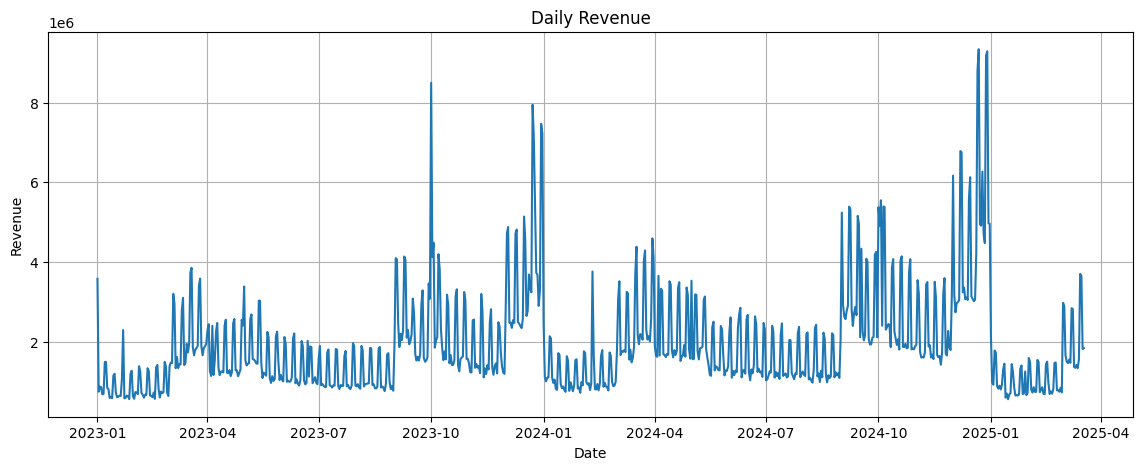

In [7]:
plt.figure(figsize=(14,5))

plt.plot(daily_sales["Date"], daily_sales["Revenue"])

plt.title("Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [8]:
daily_sales = daily_sales.set_index("Date")

daily_sales = daily_sales.asfreq("D")

daily_sales.head()

,Revenue
Date,
2023-01-01,3577274.80
2023-01-02,744383.07
2023-01-03,870557.45
2023-01-04,857408.24
2023-01-05,675058.69


In [9]:
daily_sales.isna().sum()

Revenue    0
dtype: int64

In [10]:
forecast_df = daily_sales.reset_index()

forecast_df.columns = ["ds", "y"]

forecast_df.head()

,ds,y
0,2023-01-01,3577274.80
1,2023-01-02,744383.07
2,2023-01-03,870557.45
3,2023-01-04,857408.24
4,2023-01-05,675058.69


In [11]:
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [12]:
model = Prophet()

model.fit(forecast_df)

12:18:37 - cmdstanpy - INFO - Chain [1] start processing
12:18:38 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

In [14]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
833,2025-04-13,3.169868e+06,2.365538e+06,4.044137e+06
834,2025-04-14,1.700761e+06,8.545041e+05,2.513624e+06
835,2025-04-15,1.626742e+06,8.879421e+05,2.473492e+06
836,2025-04-16,1.616669e+06,8.158411e+05,2.401450e+06
837,2025-04-17,1.568860e+06,8.742162e+05,2.412636e+06


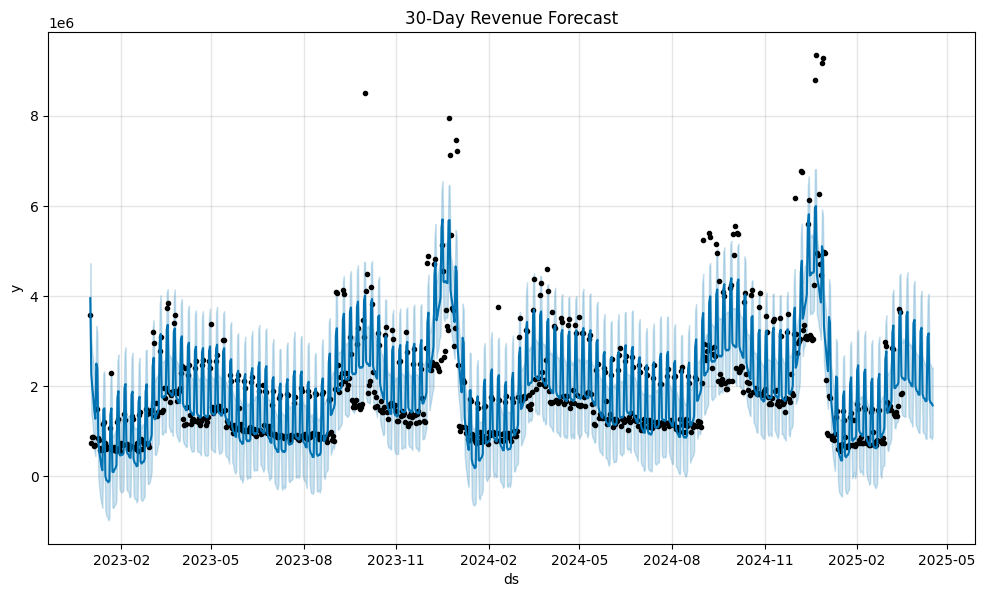

In [15]:
fig = model.plot(forecast)

plt.title("30-Day Revenue Forecast")
plt.show()